## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
out_dir = project_dir / "out"

In [2]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

from calculate_metrics import calculate_metrics

andes.config_logger(stream_level=30)

In [3]:
# base case file
case_path = test_case_dir / "regf2_testbench.xlsx"

## Run TDS Sweep

In [4]:
# anything w/o units is in p.u. 
metrics = pd.DataFrame({
    "Tr (s)": [], 
    "Pref": [],
    "Peak Inertial Power": [],
    "Power Available":[],
    "H_RMSE (s)": [],
    "Max RoCoF":[],
    "Nadir":[]
})

# save a few time-series for visualization
M_series = pd.DataFrame({
})

In [44]:
STEP_TIME = 0.01 # 10 ms
Tr_vals = np.linspace(0, 0.05, 51)
#Tr_vals = np.linspace(0, 0.05, 51) # rerun to get more granular time-series
H_rec_vals = np.linspace(0, 0.1, 11)

print(Tr_vals)
print(H_rec_vals)

[0.    0.002 0.004 0.006 0.008 0.01  0.012 0.014 0.016 0.018 0.02  0.022
 0.024 0.026 0.028 0.03  0.032 0.034 0.036 0.038 0.04  0.042 0.044 0.046
 0.048 0.05  0.052 0.054 0.056 0.058 0.06  0.062 0.064 0.066 0.068 0.07
 0.072 0.074 0.076 0.078 0.08  0.082 0.084 0.086 0.088 0.09  0.092 0.094
 0.096 0.098 0.1  ]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1 ]


In [45]:
metrics = metrics.iloc[0:0]

for tr in Tr_vals:
    # load a new case
    base_case = andes.get_case(case_path)
    ss = andes.load(base_case, setup=False)

    # change Tr
    ss.REGF2.set('Tr', 1, tr) # independent variable
    record_M = tr in H_rec_vals

    print(f"Running TDS for Tr = {ss.REGF2.Tr.v}. Recording = {record_M}")

    # TDS
    ss.setup()
    ss.config.warn_abnormal = 1
    ss.PFlow.run()

    ss.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
    ss.TDS.config.fixt = 1 # fixed step size
    ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

    ss.TDS.config.no_tqdm = 1
    ss.TDS.config.criteria = 1
    ss.TDS.run()

    # metrics
    metrics, M_series = calculate_metrics(ss, metrics, M_series, record_M=record_M)

print("All done!")

Running TDS for Tr = [np.float64(0.0)]. Recording = True
Running TDS for Tr = [np.float64(0.002)]. Recording = False
Running TDS for Tr = [np.float64(0.004)]. Recording = False
Running TDS for Tr = [np.float64(0.006)]. Recording = False
Running TDS for Tr = [np.float64(0.008)]. Recording = False
Running TDS for Tr = [np.float64(0.01)]. Recording = True
Running TDS for Tr = [np.float64(0.012)]. Recording = False
Running TDS for Tr = [np.float64(0.014)]. Recording = False
Running TDS for Tr = [np.float64(0.016)]. Recording = False
Running TDS for Tr = [np.float64(0.018000000000000002)]. Recording = False
Running TDS for Tr = [np.float64(0.02)]. Recording = True
Running TDS for Tr = [np.float64(0.022)]. Recording = False
Running TDS for Tr = [np.float64(0.024)]. Recording = False
Running TDS for Tr = [np.float64(0.026000000000000002)]. Recording = False
Running TDS for Tr = [np.float64(0.028)]. Recording = False
Running TDS for Tr = [np.float64(0.03)]. Recording = True
Running TDS for Tr 

In [ ]:
metrics.to_excel(f"{project_dir}/out/isolated_controller/1_no_noise/metrics_sheet.xlsx")

## Visualizaton

In [ ]:
metrics.set_index("Tr (s)")
x_tr = metrics["Tr (s)"]

In [ ]:
#metrics2 = metrics.loc[:25]
#metrics2
#etrics = metrics2


### Peak Delivered Power vs. Tr

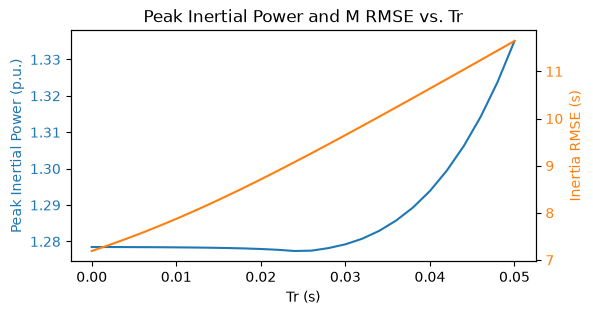

In [69]:
y_1 = metrics["Peak Inertial Power"]
y_power_avail = metrics["Power Available"]

fig, ax1 = plt.subplots(figsize=(6, 3))

ax1.set_title("Peak Inertial Power and M RMSE vs. Tr")

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Peak Inertial Power (p.u.)', color=color) # y-axis
ax1.plot(x_tr, y_1, color=color, label="Highest REGF2.Pe")
ax1.tick_params(axis='y', labelcolor=color)

# Second Y-Axis (Right Side)
y_rmse = metrics["H_RMSE (s)"]

# Second Y-Axis (Left side)
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_xlabel('Tr (s)')
ax2.set_ylabel('Inertia RMSE (s)', color=color)
ax2.plot(x_tr, y_rmse, color=color)
ax2.tick_params(axis='y', labelcolor=color)


#ax1.set_xlim(0, 0.1)

### Max RoCoF and Nadir vs. Tr

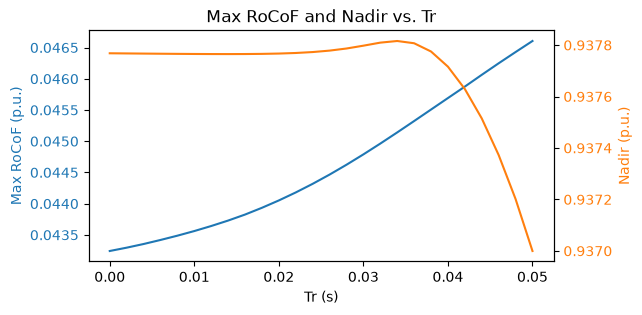

In [70]:
y_1 = metrics["Max RoCoF"]
y_2 = metrics["Nadir"]

fig, ax1 = plt.subplots(figsize=(6, 3))
ax1.set_title("Max RoCoF and Nadir vs. Tr")

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Max RoCoF (p.u.)', color=color)
ax1.plot(x_tr, y_1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Second Y-Axis (Right side)
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:orange'
ax2.set_ylabel('Nadir (p.u.)', color=color)
ax2.plot(x_tr, y_2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()

### Plotting Estimated H Time-Series for Selected Values of Tr 

In [5]:
M_gfm = ss.REGF2.mf.v
time_invalid = 1 + STEP_TIME * 20

cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 3))

for i, tr_val in enumerate(M_series.columns):
    if (i % 1 == 0) and (tr_val < 0.05) :
        color = cmap(i / (len(M_series.columns) - 1))
        ax.plot(M_series.index, M_series[tr_val] / 2, color=color, linewidth=1.8,
                label=f"Tr = {tr_val:.2f}s", zorder = 10 - i)

plt.axline((0, M_gfm), slope=0, color="purple", linestyle=":", label=f"$H_{{nominal}}$")
ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
    
ax.set_xlabel("Time (s)")
ax.set_ylabel("Estimated Inertia (s)")

ax.set_title(f"Estimated Inertia For Values of Tr")
ax.legend(loc="upper right", fontsize=7, framealpha=0.9)
ax.set_xlim(5, 6)
ax.set_ylim(5, 30)

NameError: name 'ss' is not defined

In [71]:
M_series.to_excel(f"{project_dir}/out/isolated_controller/1_no_noise/M_timeseries_reasonable.xlsx")

In [42]:
M_series

,0.00,0.01,0.02,0.03,0.04,0.05,0.50,0.42,0.06,0.07,0.08,0.09,0.10
5.100000,51.028665,69.336032,94.880480,127.130911,166.744594,215.492026,-435.259329,-474.046834,276.349988,354.085089,456.559735,597.575441,803.676840
5.100100,50.833222,68.999920,94.307013,126.189479,165.244676,213.142811,-441.472448,-481.551779,272.689970,348.348346,447.401368,582.451854,777.260149
5.100200,50.642775,68.671411,93.745953,125.268844,163.780199,210.855060,-447.887334,-489.322274,269.138981,342.811029,438.623673,568.100488,752.557296
5.110200,37.594685,47.409644,59.807474,73.669060,88.364880,103.616643,1166.781739,909.028690,119.293868,135.330332,151.690526,168.354978,185.313233
5.120200,30.187001,36.539916,44.315001,52.706784,61.231913,69.674636,278.409580,256.773969,77.939211,85.983010,93.788516,101.350834,108.671690
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5.966867,14.156669,14.264416,14.318867,14.251097,14.016108,13.680075,28.278419,24.171279,13.365448,13.150369,13.046425,13.027286,13.058065
5.976867,14.311653,14.430626,14.503770,14.457841,14.233187,13.882626,27.866651,23.735721,13.531138,13.268978,13.118066,13.056967,13.051583
5.986867,14.465822,14.595874,14.688688,14.668004,14.459527,14.100384,27.451046,23.278421,13.715692,13.407409,13.208666,13.103884,13.060381
5.996867,14.626002,14.767580,14.880865,14.888468,14.701862,14.340334,27.042128,22.806844,13.926507,13.573387,13.326110,13.175966,13.092358
